<a href="https://colab.research.google.com/github/Jonathan-ops-del/Aggregate-Merge-Data-with-Pandas-Analyse-the-Lego-Dataset/blob/main/Lego_Analysis_for_Course_(start).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Today we'll dive deep into a dataset all about LEGO. From the dataset we can ask whole bunch of interesting questions about the history of the LEGO company, their product offering, and which LEGO set ultimately rules them all:

<ul type="square">
<li>What is the most enormous LEGO set ever created and how many parts did it have?</li>

<li>How did the LEGO company start out? In which year were the first LEGO sets released and how many sets did the company sell when it first launched?</li>

<li>Which LEGO theme has the most sets? Is it one of LEGO's own themes like Ninjago or a theme they licensed liked Harry Potter or Marvel Superheroes?</li>

<li>When did the LEGO company really expand its product offering? Can we spot a change in the company strategy based on how many themes and sets did it released year-on-year?</li>

<li>Did LEGO sets grow in size and complexity over time? Do older LEGO
sets tend to have more or fewer parts than newer sets?</li>
</ul>

**Data Source**

[Rebrickable](https://rebrickable.com/downloads/) has compiled data on all the LEGO pieces in existence. I recommend you use download the .csv files provided in this lesson.

# Import Statements

In [ ]:
import pandas as pd

# Data Exploration

In [ ]:
colors = pd.read_csv('colors.csv')

In [ ]:
colors.head()

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


In [ ]:
colors.groupby('name').count()

,id,rgb,is_trans
name,,,
Aqua,1,1,1
Black,1,1,1
Blue,1,1,1
Blue-Violet,1,1,1
Bright Green,1,1,1
...,...,...,...
Violet,1,1,1
White,1,1,1
Yellow,1,1,1


In [ ]:
colors['name'].nunique()

135

**Challenge**: Find the number of transparent colours where <code>is_trans == 't'</code> versus the number of opaque colours where <code>is_trans == 'f'</code>. See if you can accomplish this in two different ways.

In [ ]:
colors.groupby('is_trans').count()

,id,name,rgb
is_trans,,,
f,107,107,107
t,28,28,28


In [ ]:
colors['is_trans'].nunique()

2

In [ ]:
colors.is_trans.value_counts()

,count
is_trans,
f,107
t,28


**Challenge**: Change this into an h3 section heading: Understanding LEGO Themes vs. LEGO Sets

<h3>Understanding LEGO Themes vs. LEGO Sets</h3>

Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.

**Challenge**: Display this image: https://i.imgur.com/aKcwkSx.png

<img src=" https://i.imgur.com/aKcwkSx.png">


A lego set is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.

**Challenge**: Display this image https://i.imgur.com/whB1olq.png

<img src="https://i.imgur.com/whB1olq.png">

The <code>sets.csv</code> data contains a list of sets over the years and the number of parts that each of these sets contained.

**Challenge**: Read the sets.csv data and take a look at the first and last couple of rows.

In [ ]:
import pandas as pd

In [ ]:
sets = pd.read_csv('sets.csv')

In [ ]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


**Challenge**: In which year were the first LEGO sets released and what were these sets called?

In [ ]:
sets['year'].idxmin()

9521

In [ ]:
sets.loc[9521]

,9521
set_num,700.1-1
name,Extra-Large Gift Set (ABB)
year,1949
theme_id,365
num_parts,142


In [ ]:
sets['year'].loc[9521]

np.int64(1949)

In [ ]:
sets.sort_values('year').head()

,set_num,name,year,theme_id,num_parts
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9534,700.2-1,Large Gift Set (ABB),1949,365,178


**Challenge**: How many different sets did LEGO sell in their first year? How many types of LEGO products were on offer in the year the company started?

In [ ]:
sets[sets['year'] == 1949]

,set_num,name,year,theme_id,num_parts
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9534,700.2-1,Large Gift Set (ABB),1949,365,178
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12


In [ ]:
sets['year'].loc[9521]

np.int64(1949)

In [ ]:
sets.loc[9521]

,9521
set_num,700.1-1
name,Extra-Large Gift Set (ABB)
year,1949
theme_id,365
num_parts,142


**Challenge**: Find the top 5 LEGO sets with the most number of parts.

In [ ]:
sets.sort_values('num_parts',ascending=False).head()

,set_num,name,year,theme_id,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987
11183,75192-1,UCS Millennium Falcon,2017,171,7541
10551,71043-1,Hogwarts Castle,2018,246,6020
295,10256-1,Taj Mahal,2017,673,5923
221,10189-1,Taj Mahal,2008,673,5922


**Challenge**: Use <code>.groupby()</code> and <code>.count()</code> to show the number of LEGO sets released year-on-year. How do the number of sets released in 1955 compare to the number of sets released in 2019?

In [ ]:
sets_by_year = sets.groupby('year').count()

In [ ]:
sets_by_year

,set_num,name,theme_id,num_parts
year,,,,
1949,5,5,5,5
1950,6,6,6,6
1953,4,4,4,4
1954,14,14,14,14
1955,28,28,28,28
...,...,...,...,...
2017,786,786,786,786
2018,816,816,816,816
2019,840,840,840,840


In [ ]:
sets_by_year = sets.groupby('year')['set_num'].count()

In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(sets_by_year)

year
1949      5
1950      6
1953      4
1954     14
1955     28
1956     13
1957     20
1958     46
1959      4
1960      3
1961     22
1962     41
1963     20
1964     18
1965     13
1966    111
1967     28
1968     39
1969     81
1970     37
1971     51
1972     39
1973     70
1974     39
1975     39
1976     76
1977     99
1978     78
1979     92
1980    102
1981     84
1982     84
1983     73
1984     95
1985    168
1986    159
1987    233
1988     80
1989    134
1990    108
1991    148
1992    135
1993    137
1994    164
1995    175
1996    198
1997    255
1998    381
1999    340
2000    367
2001    383
2002    504
2003    441
2004    395
2005    351
2006    313
2007    315
2008    341
2009    421
2010    435
2011    503
2012    607
2013    605
2014    690
2015    774
2016    757
2017    786
2018    816
2019    840
2020    674
2021      3
Name: set_num, dtype: int64


In [ ]:
sets_by_year = sets.groupby('year').count()

In [ ]:
sets_by_year

,set_num,name,theme_id,num_parts
year,,,,
1949,5,5,5,5
1950,6,6,6,6
1953,4,4,4,4
1954,14,14,14,14
1955,28,28,28,28
...,...,...,...,...
2017,786,786,786,786
2018,816,816,816,816
2019,840,840,840,840


In [ ]:
sets_by_year['set_num'].head()

,set_num
year,
1949,5
1950,6
1953,4
1954,14
1955,28


In [1]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

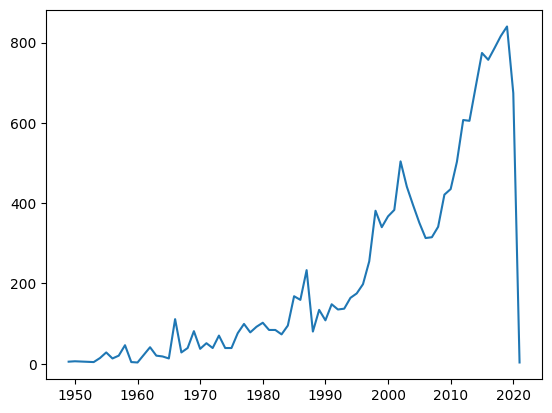

In [ ]:
plt.plot(sets_by_year.index,sets_by_year.set_num)

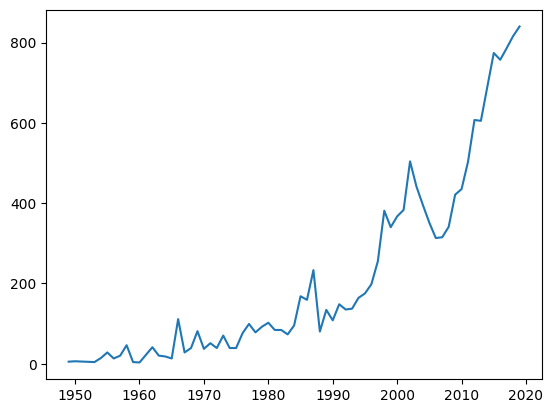

In [ ]:
plt.plot(sets_by_year.index[:-2],sets_by_year.set_num[:-2])

### Aggregate Data with the Python .agg() Function

Let's work out the number of different themes shipped by year. This means we have to count the number of unique theme_ids per calendar year.

In [ ]:
import pandas as pd

In [ ]:
sets=pd.read_csv('sets.csv')

In [ ]:
themes_by_year = sets.groupby('year').agg({'theme_id':pd.Series.nunique})

In [ ]:
themes_by_year.rename(columns={'theme_id':'nr_themes'},inplace=True)

In [ ]:
themes_by_year.head()

,nr_themes
year,
1949,2
1950,1
1953,2
1954,2
1955,4


In [ ]:
themes_by_year.tail()

,nr_themes
year,
2017,89
2018,93
2019,78
2020,82
2021,1


**Challenge**: Plot the number of themes released by year on a line chart. Only include the full calendar years (i.e., exclude 2020 and 2021).

In [ ]:
import matplotlib.pyplot as plt

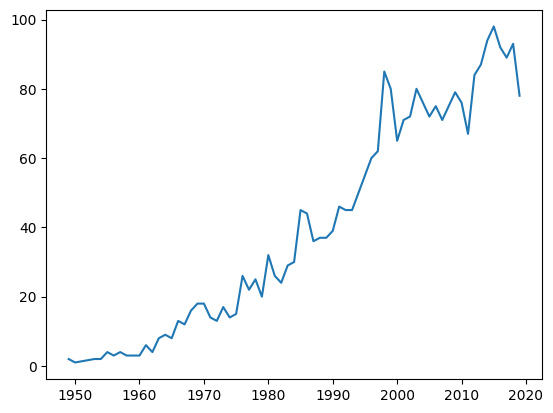

In [ ]:
plt.plot(themes_by_year.index[:-2],themes_by_year.nr_themes[:-2])

### Line Charts with Two Seperate Axes

**Challenge**: Use the <code>.groupby()</code> and <code>.agg()</code> function together to figure out the average number of parts per set. How many parts did the average LEGO set released in 1954 compared to say, 2017?

In [ ]:
parts_per_year = sets.groupby('year').agg({'num_parts': 'mean'})
parts_per_year.head()

,num_parts
year,
1949,99.600000
1950,1.000000
1953,13.500000
1954,12.357143
1955,36.607143


In [ ]:
parts_per_year.loc[1954]

,1954
num_parts,12.357143


In [ ]:
parts_per_year.loc[2017]

,2017
num_parts,221.840967


### Scatter Plots in Matplotlib

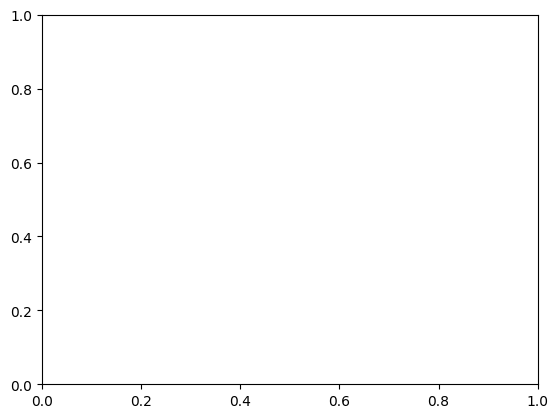

In [ ]:
ax1 = plt.gca()

In [ ]:
ax2 = ax1.twinx()

In [ ]:
sets_by_year = sets.groupby('year').count()

In [ ]:
sets_by_year['set_num'].head()

,set_num
year,
1949,5
1950,6
1953,4
1954,14
1955,28


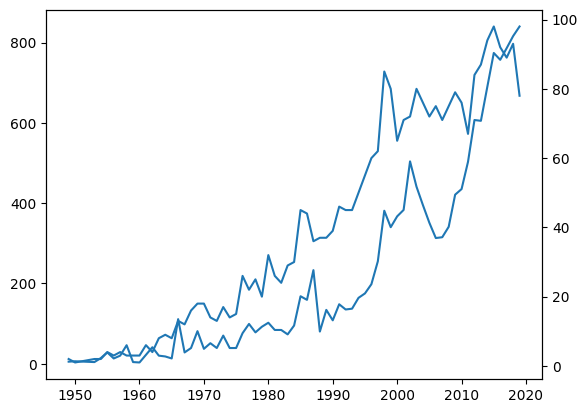

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2])
ax2.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2])
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2])
ax2.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2])


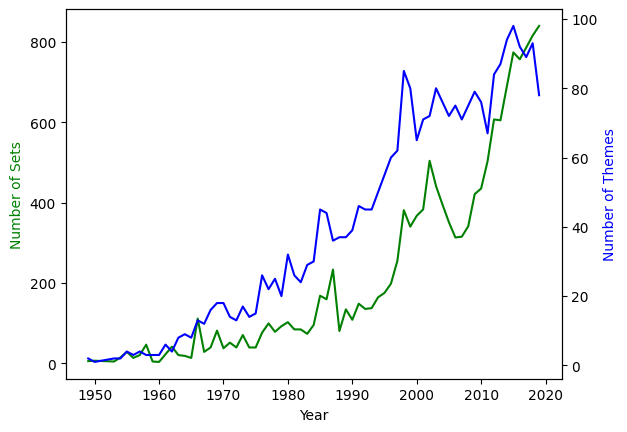

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2],color='g')
ax2.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2],'b')

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Sets',color='green')
ax2.set_ylabel('Number of Themes',color='blue')
plt.show()


**Challenge**: Has the size and complexity of LEGO sets increased over time based on the number of parts? Plot the average number of parts over time using a Matplotlib scatter plot. See if you can use the [scatter plot documentation](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.scatter.html) before I show you the solution. Do you spot a trend in the chart?

In [ ]:
parts_per_year = sets.groupby('year').agg({'num_parts': pd.Series.mean})
parts_per_year.head()

,num_parts
year,
1949,99.600000
1950,1.000000
1953,13.500000
1954,12.357143
1955,36.607143


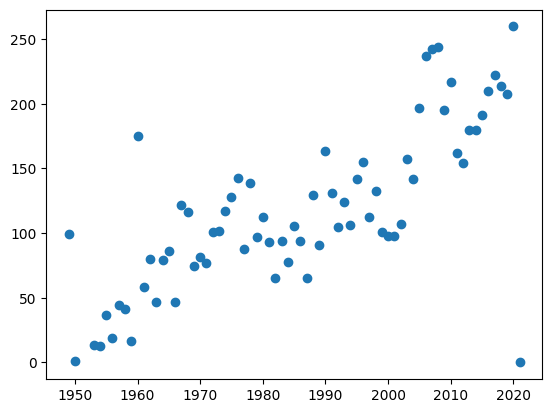

In [ ]:
plt.scatter(parts_per_year.index,parts_per_year.num_parts)

### Number of Sets per LEGO Theme

LEGO has licensed many hit franchises from Harry Potter to Marvel Super Heros to many others. But which theme has the largest number of individual sets?

**Challenge**: Explore the themes.csv. How is it structured? Search for the name 'Star Wars'. How many <code>id</code>s correspond to this name in the themes.csv? Now use these <code>id</code>s and find the corresponding the sets in the sets.csv (Hint: you'll need to look for matches in the <code>theme_id</code> column)

In [ ]:
set_theme_count=sets["theme_id"].value_counts()

In [ ]:
set_theme_count[:5]

,count
theme_id,
158,753
501,656
494,398
435,356
503,329


<img src="https://i.imgur.com/Sg4lcjx.png">

In [ ]:
themes=pd.read_csv('themes.csv')

In [ ]:
themes.head()

,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0


In [ ]:
themes[themes.name == "Star Wars"]

,id,name,parent_id
17,18,Star Wars,1.0
150,158,Star Wars,NaN
174,209,Star Wars,207.0
211,261,Star Wars,258.0


In [ ]:
sets[sets.theme_id == 18]

,set_num,name,year,theme_id,num_parts
8786,65081-1,R2-D2 / C-3PO Droid Collectors Set,2002,18,1
12051,8000-1,Pit Droid,2000,18,223
12058,8001-1,Battle Droid,2000,18,336
12066,8002-1,Destroyer Droid,2000,18,567
12071,8007-1,C-3PO,2001,18,339
12072,8008-1,Stormtrooper,2001,18,360
12073,8009-1,R2-D2,2002,18,239
12074,8010-1,Darth Vader,2002,18,388
12081,8011-1,Jango Fett,2002,18,425
12083,8012-1,Super Battle Droid,2002,18,378


In [ ]:
sets[sets.theme_id == 209]

,set_num,name,year,theme_id,num_parts
11013,75023-1,Star Wars Advent Calendar 2013,2013,209,254
11046,75056-1,Star Wars Advent Calendar 2014,2014,209,273
11080,75097-1,Star Wars Advent Calendar 2015,2015,209,291
11131,75146-1,Star Wars Advent Calendar 2016,2016,209,282
11173,75184-1,Star Wars Advent Calendar 2017,2017,209,309
11206,75213-1,Star Wars Advent Calendar 2018,2018,209,307
11245,75245-1,Star Wars Advent Calendar 2019,2019,209,280
11281,75279-1,Star Wars Advent Calendar 2020,2020,209,312
12019,7958-1,Star Wars Advent Calendar 2011,2011,209,267
14352,9509-1,Star Wars Advent Calendar 2012,2012,209,235


### Merging (i.e., Combining) DataFrames based on a Key


In [ ]:
set_theme_count=pd.DataFrame({"id":set_theme_count.index,"set_count":set_theme_count.values})

In [ ]:
set_theme_count.head()

,id,set_count
0,158,753
1,501,656
2,494,398
3,435,356
4,503,329


In [ ]:
merged_df=pd.merge(set_theme_count,themes,on='id')

In [ ]:
merged_df[:3]

,id,set_count,name,parent_id
0,158,753,Star Wars,NaN
1,501,656,Gear,NaN
2,494,398,Friends,NaN


In [ ]:
import matplotlib.pyplot as plt

<BarContainer object of 10 artists>

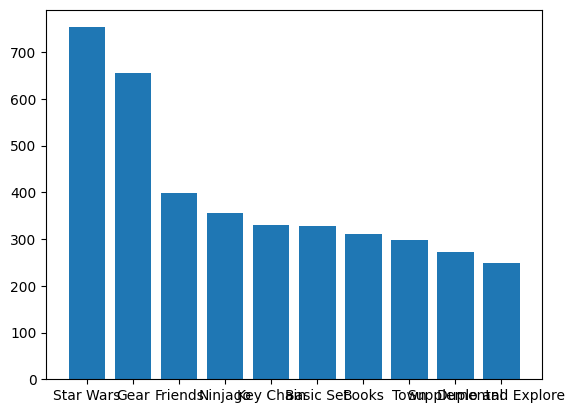

In [ ]:
plt.bar(merged_df.name[:10],merged_df.set_count[:10])

<BarContainer object of 10 artists>

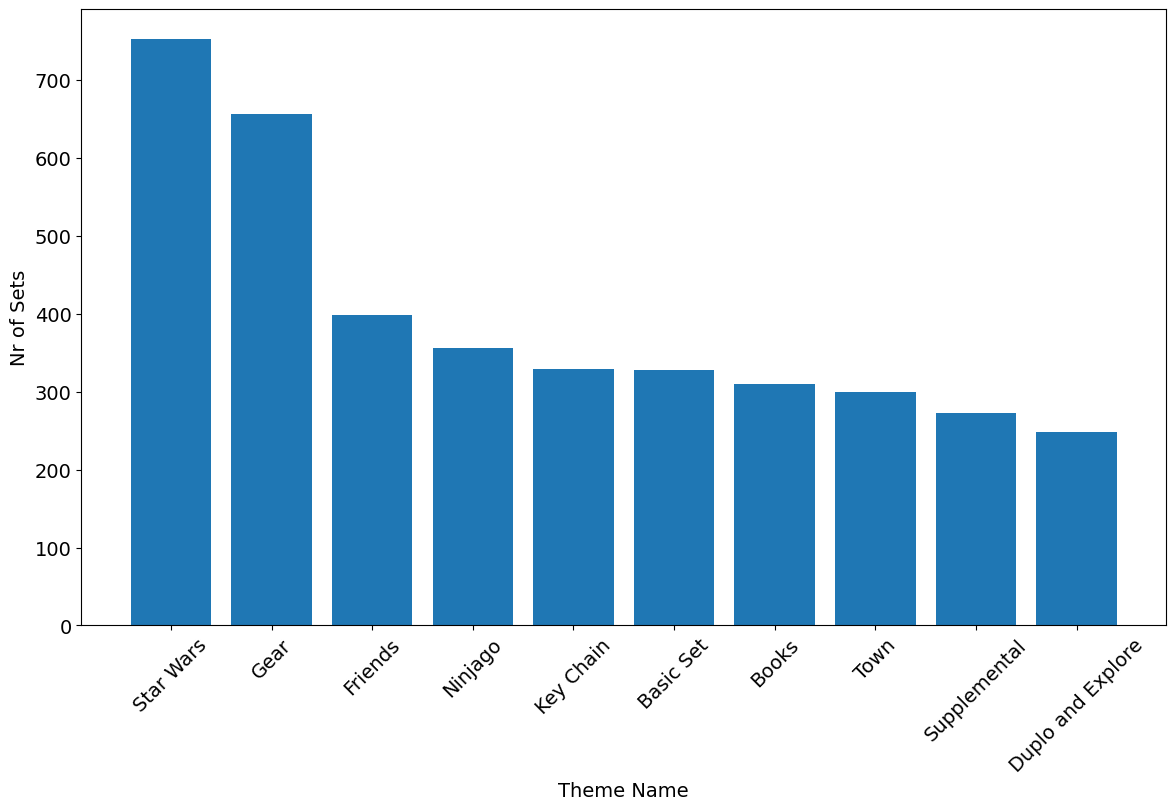

In [ ]:
plt.figure(figsize=(14,8))
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.ylabel('Nr of Sets', fontsize=14)
plt.xlabel('Theme Name', fontsize=14)

plt.bar(merged_df.name[:10], merged_df.set_count[:10])